# Predictive Maintenance - Machine Temperature Anomaly Detection

## Objective
Detect abnormal machine behavior using time-series temperature data.

## Step 1
Load dataset and visualize temperature trend.

In [27]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

In [28]:

#Load dataset directly from Github
url = "https://raw.githubusercontent.com/numenta/NAB/master/data/realKnownCause/machine_temperature_system_failure.csv"
df = pd.read_csv(url)
df.head()

,timestamp,value
0,2013-12-02 21:15:00,73.967322
1,2013-12-02 21:20:00,74.935882
2,2013-12-02 21:25:00,76.124162
3,2013-12-02 21:30:00,78.140707
4,2013-12-02 21:35:00,79.329836


In [29]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22695 entries, 0 to 22694
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  22695 non-null  object 
 1   value      22695 non-null  float64
dtypes: float64(1), object(1)
memory usage: 354.7+ KB


,value
count,22695.000000
mean,85.926498
std,13.746912
min,2.084721
25%,83.080078
50%,89.408246
75%,94.016252
max,108.510543


In [30]:
# Convert timestamp to datetime

df['timestamp'] = pd.to_datetime(df['timestamp'])

In [31]:
# Checking datatypes after changing the datatype
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22695 entries, 0 to 22694
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  22695 non-null  datetime64[ns]
 1   value      22695 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 354.7 KB


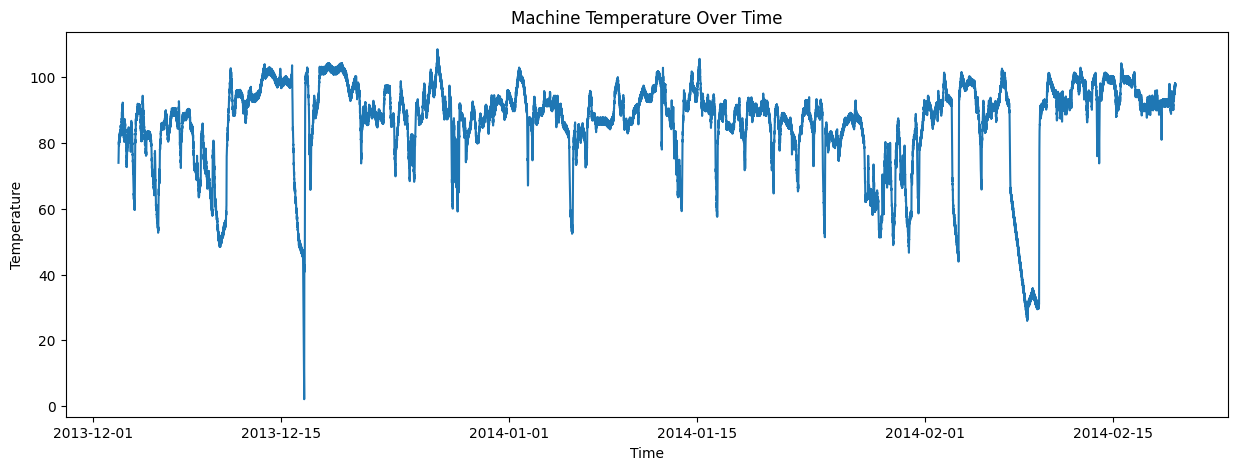

In [32]:
#Visualizing data
plt.figure(figsize=(15,5))
plt.plot(df['timestamp'],df['value'])
plt.title('Machine Temperature Over Time')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.show()

In [33]:
# setting timestamp as index
df.set_index('timestamp',inplace=True)
df.head()

,value
timestamp,
2013-12-02 21:15:00,73.967322
2013-12-02 21:20:00,74.935882
2013-12-02 21:25:00,76.124162
2013-12-02 21:30:00,78.140707
2013-12-02 21:35:00,79.329836


In [34]:
df.index.value_counts()[df.index.value_counts()>1]

,count
timestamp,
2014-01-07 02:55:00,2
2014-01-07 02:50:00,2
2014-01-07 02:45:00,2
2014-01-07 02:40:00,2
2014-01-07 02:35:00,2
2014-01-07 02:30:00,2
2014-01-07 02:25:00,2
2014-01-07 02:20:00,2
2014-01-07 02:15:00,2


In [35]:
# Remove Duplicates
df = df.groupby(level=0).mean()

In [36]:
# Basic statistics
mean = df['value'].mean()
std = df['value'].std()

print(f"Mean temperature:{mean:.2f}")
print(f"Standard Deviation:{std:.2f}")

Mean temperature:85.92
Standard Deviation:13.75


## Adding Rolling mean

After overlaying Rolling mean on the original Temperature. We are seperating two things.
1. Short Time Fluctation(noise): The Original Temperature Line
2. Underlying trend: The rolling mean line

In [37]:
# Adding Rolling mean
df['rolling_mean'] = df['value'].rolling(window=50).mean()

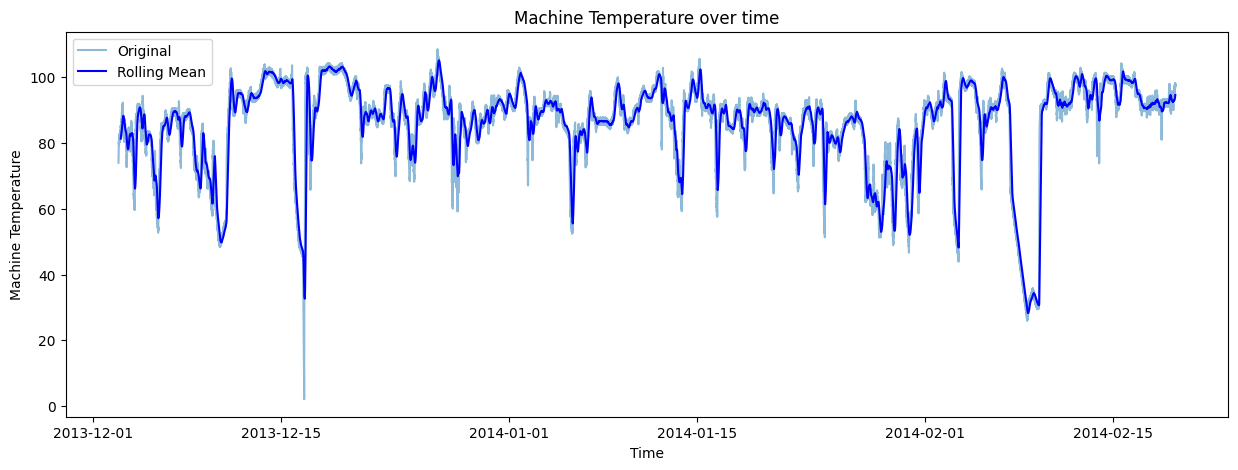

In [38]:
plt.figure(figsize=(15,5))
plt.plot(df.index,df['value'],alpha=0.5,label='Original')
plt.plot(df.index,df['rolling_mean'],label='Rolling Mean',color = 'b')
plt.legend()
plt.title('Machine Temperature over time')
plt.xlabel('Time')
plt.ylabel('Machine Temperature')
plt.show()

## Observation
During **normal operation** temperature shows random flactuation around a stable baseline.

**Event/Failure behaviour:** The system shows gradual shift in machine temperature , indicating abnormal machine behaviour.

## Statistical Threshold method
we use the 3 sigma rule to detect anomalies in machine temperature
Any value outside mean + 3 standard deviation value is marked as an anamoly.



In [39]:
# Calcaluating upper and lower limit
mean_temp = df['value'].mean()
std_temp = df['value'].std()

upper_limit = mean_temp + 3 * std_temp
lower_limit = mean_temp - 3 * std_temp

upper_limit,lower_limit

(np.float64(127.17015819617694), np.float64(44.6743597426232))

In [40]:
# Adding limit columns to dataframe
df['upper_limit'] = upper_limit
df['lower_limit'] = lower_limit

In [41]:
# Detect anomalies

df['anomaly'] = ((df['value'] > df['upper_limit']) | (df['value']<df['lower_limit']))

In [42]:
# Extract only anomalies
anomalies = df[df['anomaly']==True]
anomalies.shape

(462, 5)

## Calculate rolling mean and standard deviation

In [43]:
window = 50
rolling_mean = df['value'].rolling(window=window).mean()
rolling_std = df['value'].rolling(window=window).std()
df['rolling_mean'] = rolling_mean
df['rolling_std'] = rolling_std

## Creating rolling threshold

In [44]:
df['upper_limit_rolling'] = rolling_mean + 3*rolling_std
df['lower_limit_rolling'] = rolling_mean - 3*rolling_std

## Detecting rolling anomalies

In [45]:
df['anomal_rolling'] = (df['value']>df['upper_limit_rolling'])|(df['value']<df['lower_limit_rolling'])
df['anomal_rolling'].head()

,anomal_rolling
timestamp,
2013-12-02 21:15:00,False
2013-12-02 21:20:00,False
2013-12-02 21:25:00,False
2013-12-02 21:30:00,False
2013-12-02 21:35:00,False


## Extracting Anomalies

In [46]:
anomal_rolling = df[df['anomal_rolling']==True]
anomal_rolling.shape

(321, 9)

## Plot Rolling Detection

In [47]:
df_zoom = df.iloc[3000:5000]
anomal_rolling_zoom = anomal_rolling.iloc[30000:50000]

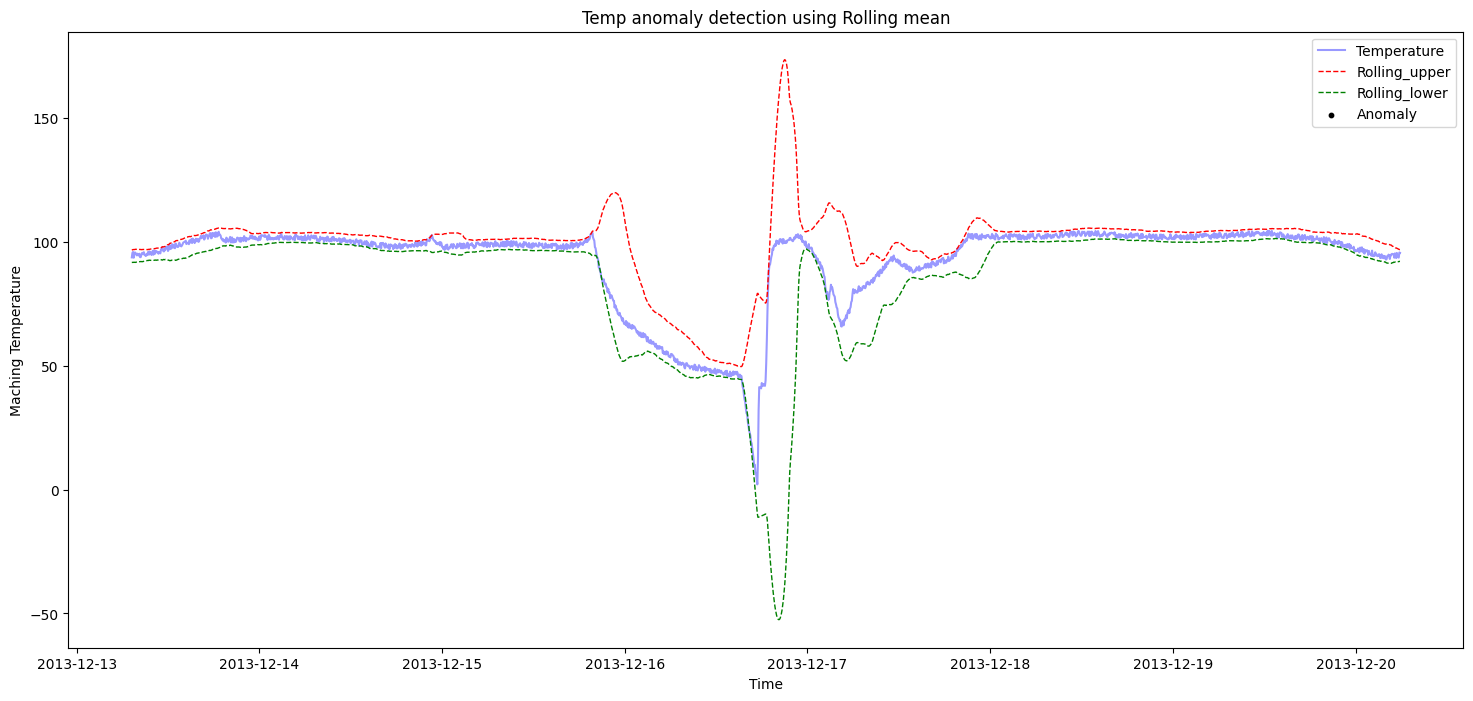

In [48]:
plt.figure(figsize=(18,8))
plt.plot(df_zoom.index,df_zoom['value'],color='b',alpha=0.4,label='Temperature')

plt.plot(df_zoom.index,df_zoom['upper_limit_rolling'],color='red',linewidth=1,linestyle = '--',label='Rolling_upper')
plt.plot(df_zoom.index,df_zoom['lower_limit_rolling'],color='green',linewidth=1,linestyle='--',label='Rolling_lower')

plt.scatter(anomal_rolling_zoom.index,anomal_rolling_zoom['value'],s=10,color='black',label='Anomaly')

plt.legend()
plt.xlabel('Time')
plt.ylabel('Maching Temperature')
plt.title('Temp anomaly detection using Rolling mean')
plt.show()

## Observation
Rolling threshold adopts to local behaviour of time series. However, large spikes within rolling window expands increases the rolling standard deviation, which expands the threshold and may prevent those spikes from being flagged as anomalies.

## Isolation Forest Anomaly detection

Isolation Forest Anomaly detection detects anomalies by isolating observations through random partitioning. Points that require fewer splits to isolate are considered anomalies

Unlike statistical threshold methods, Isolation forest does not assume a specific distribution and can detect both the spikes and gradual drift patterns in the data.

In [49]:
from sklearn.ensemble import IsolationForest

In [50]:
# Isolationforest requires feature matrix
features_basic = df[['value','rolling_mean','rolling_std']].dropna()

In [51]:
# Train the Isolation forest method
model_basic = IsolationForest(n_estimators=100,contamination=0.01,random_state=42)
model_basic.fit(features_basic)

IsolationForest(contamination=0.01, random_state=42)

In [53]:
#Predict Anomalies
features_basic['anomaly_iforest_basic']=model_basic.predict(features_basic)

In [54]:
#Merge the predicted col to df
df.loc[features_basic.index,'anomaly_iforest_basic'] = features_basic['anomaly_iforest_basic']

In [55]:
#Extract Anomalies
anomalies_Iforest = features_basic[features_basic['anomaly_iforest_basic']==-1]
anomalies_Iforest.shape

(226, 4)

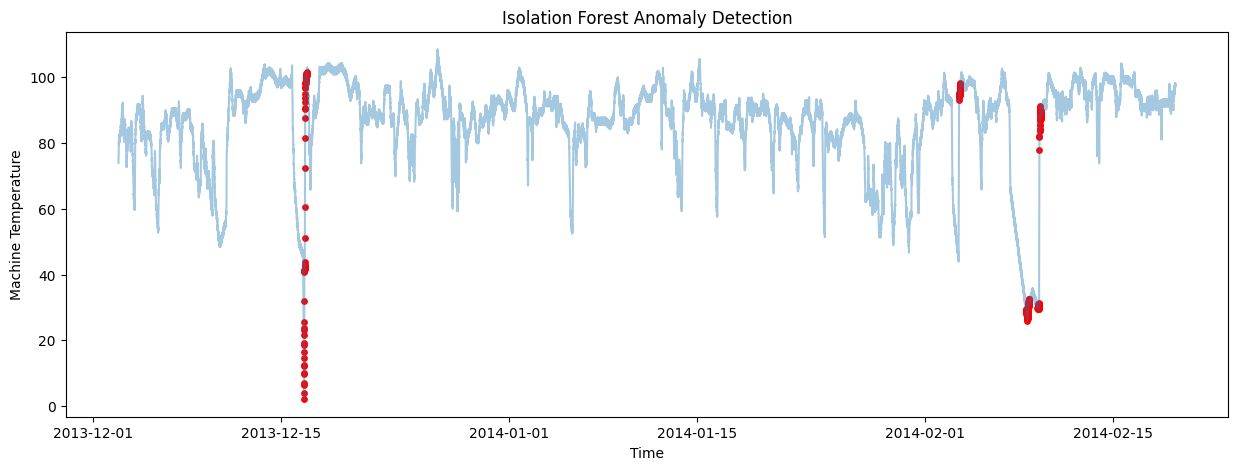

In [56]:
#Plot Isolation Forestresult

plt.figure(figsize=(15,5))
plt.plot(df.index,df['value'],alpha=0.4,label='Temperature')
plt.scatter(anomalies_Iforest.index,anomalies_Iforest['value'],color='red',s=15,label='Isolation Forest Anomaly')

plt.title('Isolation Forest Anomaly Detection')
plt.xlabel('Time')
plt.ylabel('Machine Temperature')
plt.legend
plt.show()

Isolation Forest successfully detects point anomalies such as sudden spikes or drops in temperature. However, gradual drift patterns are not detected effectively because the model uses primarily instantaneous features. Incorporating temporal features such as lag values and rate of change can improve drift detection.

## Create Lag Features
Lag features give the model memory of previous observations.

In [57]:
df['lag1'] = df['value'].shift(1)
df['lag2'] = df['value'].shift(2)
df['lag3'] = df['value'].shift(3)

## Create Difference Features
Difference shows rate of change

In [58]:
df['diff1'] = df['value'].diff()
df['diff2'] = df['value'].diff(2)


## Rolling Trend Feature
This mesures direction of temperature change

In [59]:
df['rolling_trend'] = df['rolling_mean'].diff()

## Rolling Range Feature
Measure variability within the window

In [60]:
df['rolling_range'] = (
    df['value'].rolling(50).max() -
    df['value'].rolling(50).min())

In [61]:
## Remove Missing Values
df_features = df.dropna()

In [62]:
features_temporal = df_features[
    [
        'value',
        'rolling_mean',
        'rolling_std',
        'lag1',
        'lag2',
        'lag3',
        'diff1',
        'diff2',
        'rolling_trend',
        'rolling_range'
    ]
]

In [63]:
model_temporal = IsolationForest(
  n_estimators= 100,
  contamination=0.01,
  random_state=42
  )
model_temporal.fit(features_temporal)

IsolationForest(contamination=0.01, random_state=42)

## Predict Anomalies

In [64]:
df_features['anomaly_iforest_lag'] = model_temporal.predict(features_temporal)

/tmp/ipykernel_519/779183367.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_features['anomaly_iforest_lag'] = model_temporal.predict(features_temporal)


In [65]:
df.loc[df_features.index,'anomaly_iforest_temporal'] = df_features['anomaly_iforest_lag']

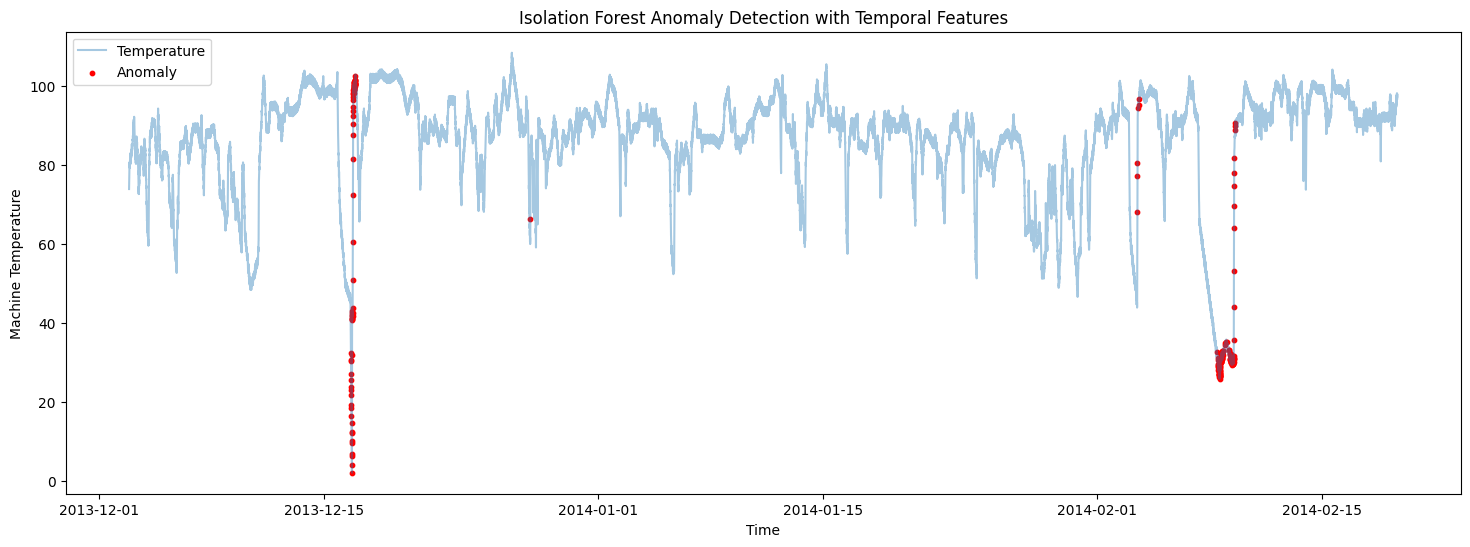

In [66]:
plt.figure(figsize=(18,6))

plt.plot(df.index,df['value'],alpha=0.4,label='Temperature')

plt.scatter(
    df[df['anomaly_iforest_temporal']==-1].index,
    df[df['anomaly_iforest_temporal']==-1]['value'],
    color = 'red',
    s = 10,
    label= 'Anomaly'
    )

plt.legend()
plt.title("Isolation Forest Anomaly Detection with Temporal Features")
plt.xlabel('Time')
plt.ylabel('Machine Temperature')
plt.show()

# Comparing Isolation Forest without temporal features vs with temporal features.

In [67]:
# compare Anomaly counts
print("Basic Model anomalies:",
      (df['anomaly_iforest_basic']==-1).sum())

print("Temporal feature anomalies:",
      (df['anomaly_iforest_temporal']==-1).sum())

Basic Model anomalies: 226
Temporal feature anomalies: 227


In [68]:
basic_anomalies = df[df['anomaly_iforest_basic']==-1]
temporal_anomalies = df[df['anomaly_iforest_temporal']==-1]

In [69]:
set(basic_anomalies.index) == set(temporal_anomalies.index)

False

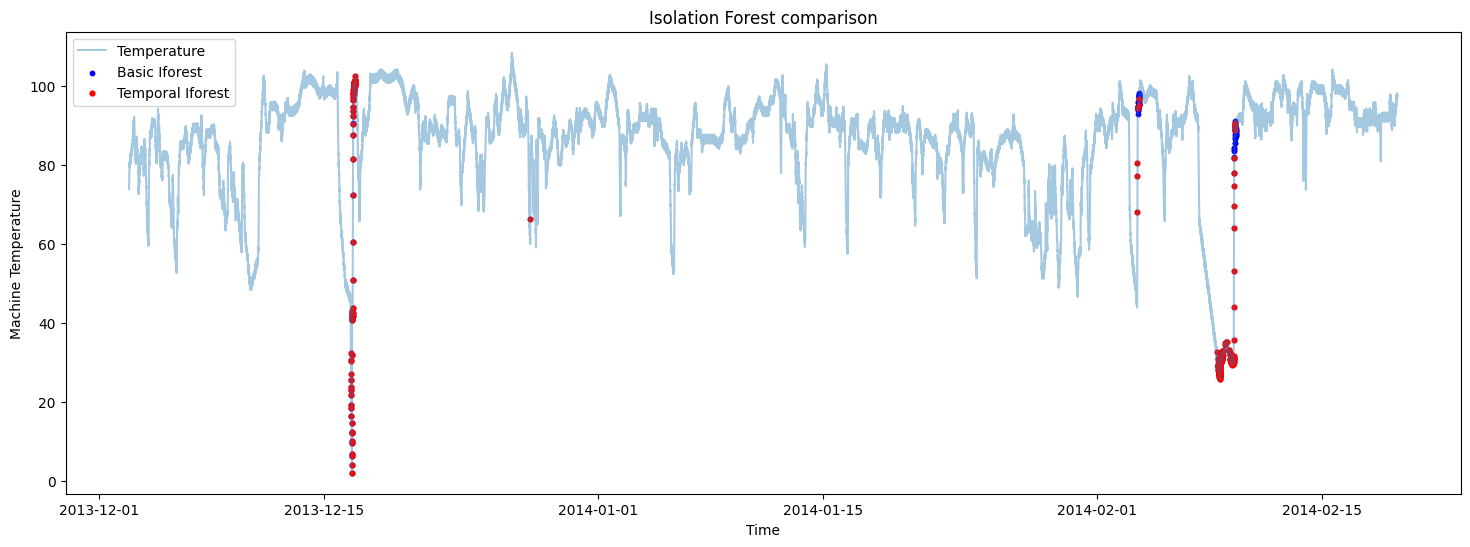

In [70]:
plt.figure(figsize=(18,6))

plt.plot(df.index,df['value'],alpha=0.4,label='Temperature')

plt.scatter(basic_anomalies.index,basic_anomalies['value'],color='blue',s=10,label = 'Basic Iforest')

plt.scatter(temporal_anomalies.index,temporal_anomalies['value'],color='r',s=12,label = 'Temporal Iforest')

plt.legend()
plt.title("Isolation Forest comparison")
plt.xlabel('Time')
plt.ylabel('Machine Temperature')
plt.show()

### Anomaly Count Comparision
 The number of anomalies detected by both models is approximately the same
 -Basic Isolation Forest model: 226 anomalies
 - Temporal Isolation Forest model: 227 anomalies.

 This similarity is expected because both models use the same cotamination parameter (0.01), which constrains the proportions of anomalies detected.

Therefore, anomaly count alone is not sufficient to evaluate model performance.


In [71]:
only_basic = df[(df['anomaly_iforest_basic'] == -1) & (df['anomaly_iforest_temporal'] != -1)]
only_temporal = df[(df['anomaly_iforest_basic']!=-1) & (df['anomaly_iforest_temporal'] == -1)]

In [72]:
# Analyze the differnce
only_basic[['value']].head(10)

,value
timestamp,
2013-12-16 19:05:00,90.726798
2014-02-03 12:40:00,93.952362
2014-02-03 12:45:00,92.999179
2014-02-03 12:50:00,94.469151
2014-02-03 12:55:00,94.896051
2014-02-03 13:00:00,93.926694
2014-02-03 13:05:00,94.415503
2014-02-03 13:10:00,94.782368
2014-02-03 13:15:00,95.079745


In [73]:
only_temporal[['value']].head(10)

,value
timestamp,
2013-12-16 15:55:00,32.454943
2013-12-16 16:00:00,30.699649
2013-12-16 16:05:00,30.504461
2013-12-16 16:10:00,27.212228
2013-12-16 21:55:00,100.528898
2013-12-16 22:00:00,100.517973
2013-12-16 22:05:00,100.154801
2013-12-16 22:15:00,101.640077
2013-12-16 22:20:00,101.129029


### Differnce analysis between models

Although both models detect a similar number of anomalies, the specific observation flagged as anomalies differ.

This is confirmed by comparing the indices of anomalies detected by each model are not identical.

This indicates that the models are capturing different types of abnormal behavior in the data.

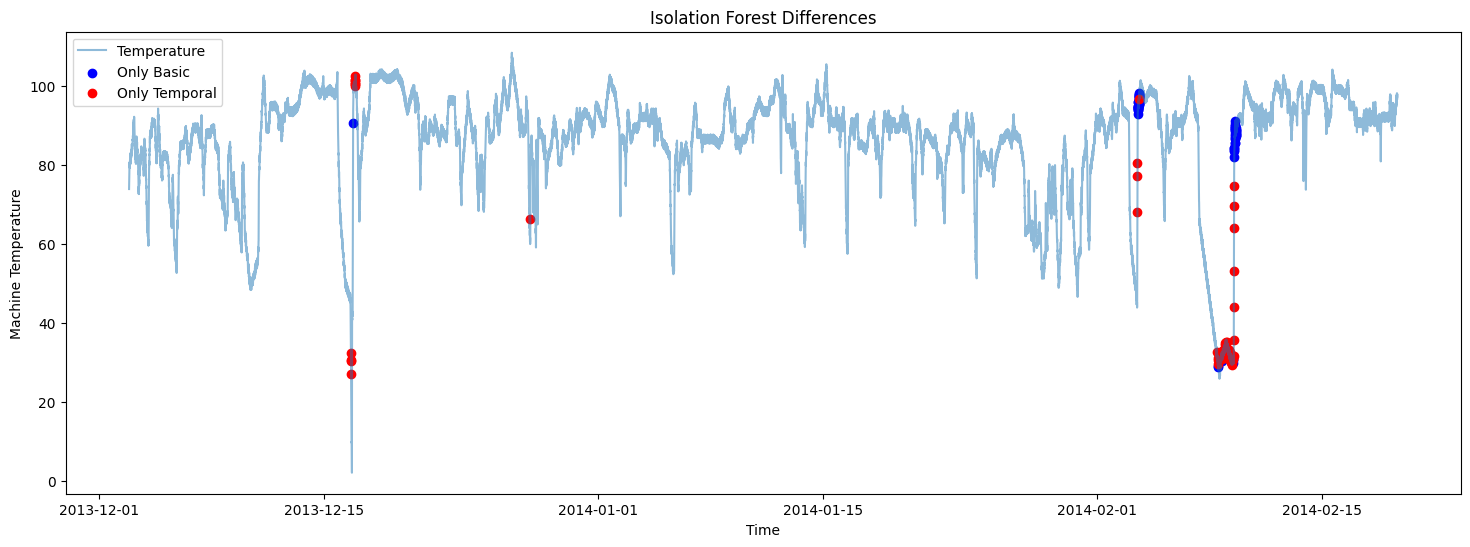

In [74]:
#Plot only differnces

plt.figure(figsize=(18,6))

plt.plot(df.index,df['value'],alpha=0.5,label='Temperature')
plt.scatter(only_basic.index,only_basic['value'],color = 'b',marker = 'o',label = 'Only Basic')
plt.scatter(only_temporal.index,only_temporal['value'],color = 'r',marker = 'o',label = 'Only Temporal')

plt.title('Isolation Forest Differences')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Machine Temperature')
plt.show()

By overlaying anomalies from both models on the temperature time series:

- The basic model ( blue point) tends to detect isolated anomalies, often corresponding to local flutuations or minor deviations

- The temporal feature model (red points) identifies clusters of anomalies in regions where the temperature shows sustained abnormal behavior.

These clustered anomalies are indicative of gradual drift or system degradation over time.

### Key Interpretation

The basic model primarily detects point anomalies, i.e., individual observations that deviate from the local distribution.

In contrast, the temporal feature model captures contextual and temporal anomalies by incorporating information about past values and rate of change.

This enables the model to identify patterns such as gradual drift, which are not easily detectable using only instantaneous statistical features.

### Conclusion

Incorporating temporal features improves anomaly detection by enabling the model to capture time-dependent behavior in the data.

While both models detect a similar number of anomalies, the temporal feature-based model provides more meaningful insights by identifying sustained abnormal patterns rather than isolated noise.

This makes the temporal model more suitable for real-world predictive maintenance applications.

This demonstrates the importance of feature engineering in improving the effectiveness of unsupervised anomaly detection models.

In [76]:
# Computing Basic Model Scores
df.loc[features_basic.index,'score_basic'] = model_basic.decision_function(features_basic[['value','rolling_mean','rolling_std']])

In [78]:
# Computing temporal model scores
df.loc[features_temporal.index,'score_temporal'] = \
  model_temporal.decision_function(features_temporal[
      [
        'value','rolling_mean','rolling_std','lag1','lag2','lag3','diff1','diff2','rolling_trend','rolling_range']
      ]
)

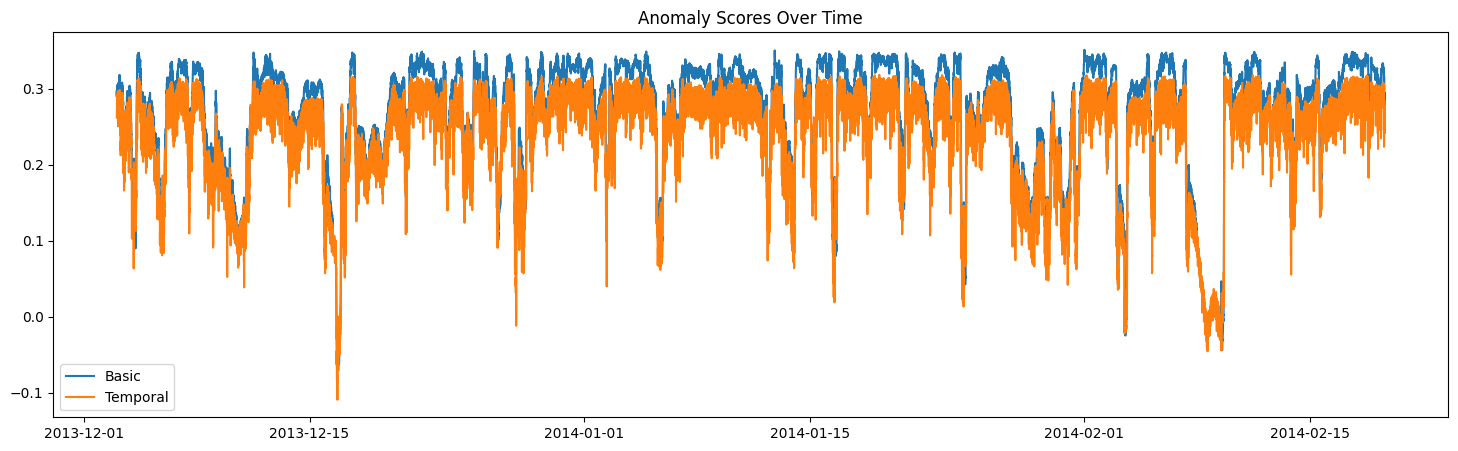

In [79]:
# Plot Score Over Time
plt.figure(figsize=(18,5))

plt.plot(df.index,df['score_basic'],label='Basic')
plt.plot(df.index,df['score_temporal'],label='Temporal')

plt.legend()
plt.title("Anomaly Scores Over Time")

plt.show()

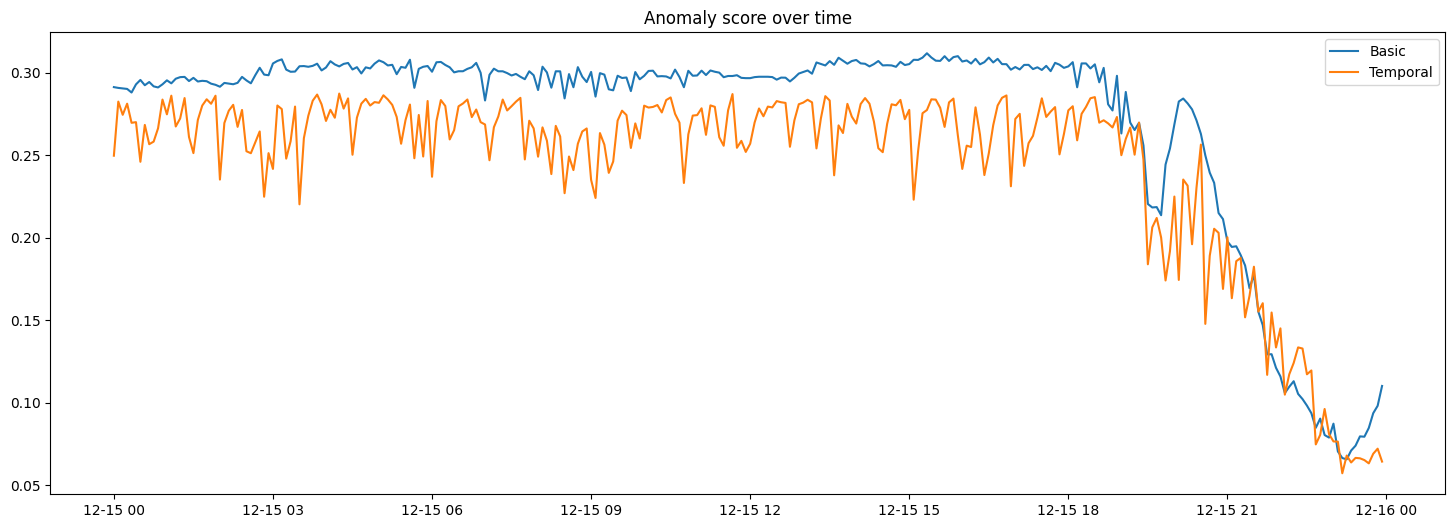

In [82]:
zoom_df = df.loc['2013-12-15':'2013-12-15']

plt.figure(figsize=(18,6))

plt.plot(zoom_df.index,zoom_df['score_basic'],label='Basic')
plt.plot(zoom_df.index,zoom_df['score_temporal'],label='Temporal')

plt.legend()
plt.title("Anomaly score over time")
plt.show()

Text(0.5, 1.0, 'Score Distribution')

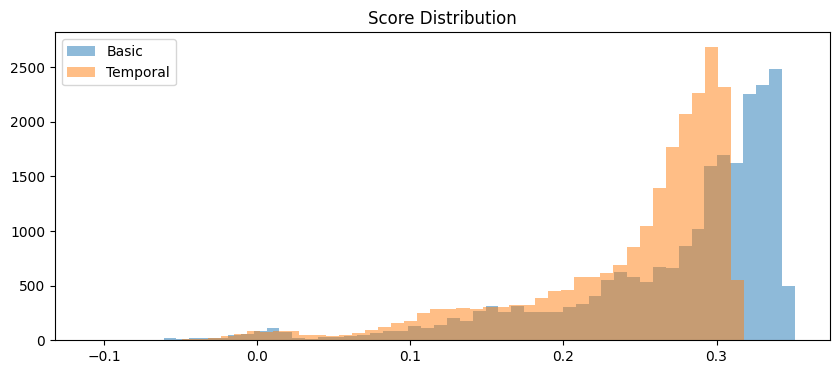

In [83]:
# Compare Score Distribution
plt.figure(figsize=(10,4))

plt.hist(df['score_basic'].dropna(),bins=50,alpha=0.5,label='Basic')
plt.hist(df['score_temporal'].dropna(),bins=50,alpha=0.5,label='Temporal')

plt.legend()
plt.title("Score Distribution")

### Anomaly Score Interpretation

The temporal feature-based model produces consistently lower anomaly scores compared to the basic model, indicating increased sensitivity to variations in the data.

However, both models exhibit similar score patterns over time, particularly in regions of sharp deviation. This suggests that the temporal features used in the current setup do not significantly enhance the detection of gradual drift.

This highlights the importance of feature engineering, as simple lag and difference features may not be sufficient to capture complex temporal patterns such as drift.